# **Numerical Data Preprocessing**

- Loading data (.csv,.xlsx etc)

- Data Cleaning

    - Handling Missing Values
    - Handling Outliers
    - Handling Duplicate Values

- Data Transformation/scaling

    - Normalization (min - max scalar)
    - Standardization (standard scalar)
    - Box - Cox transformation
    - Square root transformation
    - Log - Normal transformation


In [1]:
# import required libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [3]:
# Loading Data From CSV File
df=pd.read_csv("/content/Water_Quality.csv")
df.info()

NameError: name 'pd' is not defined

In [ ]:
df.head()

,ph,hardness,tds,chlorine,sulfate,conductivity,organic_carbon,trihalomethanes,turbidity,potability
0,7.14,440.98,614.26,2.12,208.39,350.92,7.22,17.32,2.23,0
1,6.41,242.82,387.89,3.93,313.10,153.36,9.92,20.69,2.07,0
2,6.29,133.09,225.55,1.46,332.04,1420.43,8.76,32.87,5.05,0
3,7.39,71.89,459.23,0.56,609.63,24142.89,9.62,42.80,2.26,0
4,6.31,273.01,308.99,0.64,52.59,196.85,1.05,133.38,5.30,0


In [ ]:
df["potability"].value_counts()

,count
potability,
0,92384
1,7616


# **Observations:**

1. The potability column is having discrete numerical values.
2. All the remaining columns are real numerical

<Axes: >

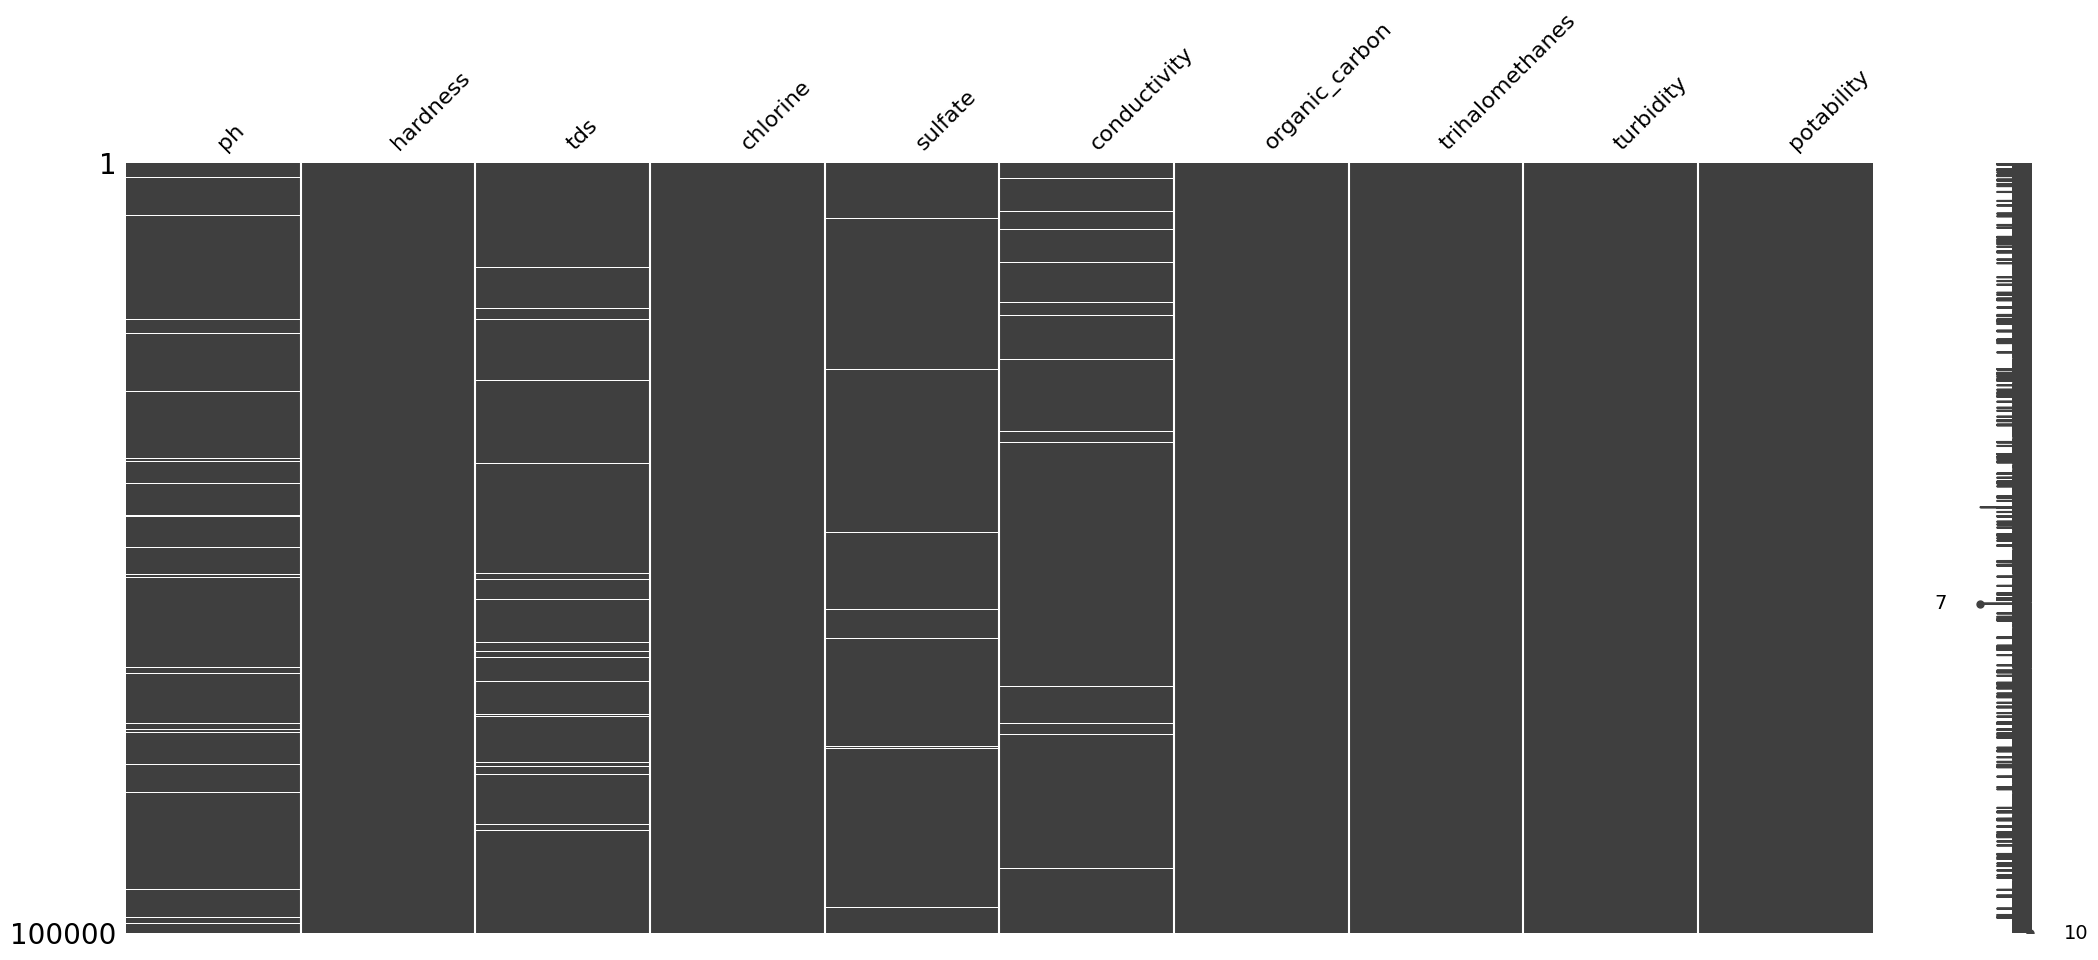

In [ ]:
import missingno as msn
msn.matrix(df)

In [ ]:
df.isnull().sum()/len(df)*100

,0
ph,3.121
hardness,0.000
tds,2.384
chlorine,0.000
sulfate,0.813
conductivity,1.598
organic_carbon,0.000
trihalomethanes,0.000
turbidity,0.000
potability,0.000


<Axes: xlabel='ph', ylabel='Density'>

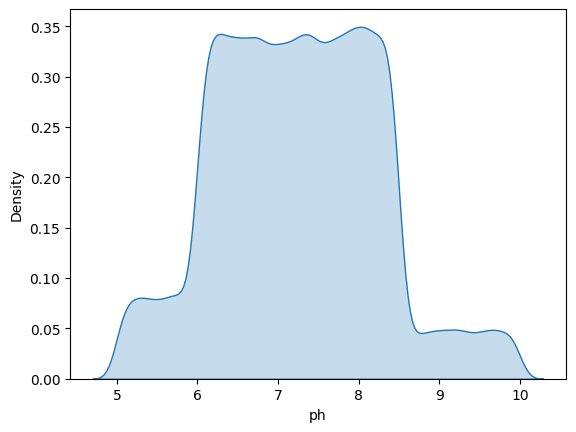

In [ ]:
sns.kdeplot(df,x="ph",fill=True)

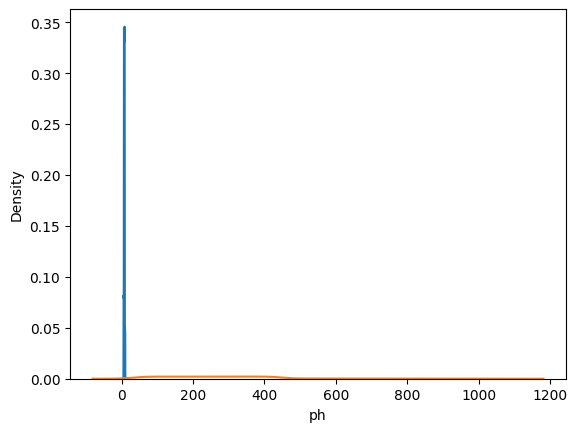

In [ ]:
sns.kdeplot(df,x="ph")
sns.kdeplot(df,x="hardness")
plt.show()

In [ ]:
sns.kdeplot(df,x="ph")

In [ ]:
# Filling Missing Values Using Simple Imputers
df["ph"]=df["ph"].fillna(df["ph"].mean())
df["tds"]=df["tds"].fillna(df["tds"].median())
df["sulfate"]=df["sulfate"].fillna(df["sulfate"].median())
df["conductivity"]=df["conductivity"].fillna(df["conductivity"].median())

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   ph               100000 non-null  float64
 1   hardness         100000 non-null  float64
 2   tds              100000 non-null  float64
 3   chlorine         100000 non-null  float64
 4   sulfate          100000 non-null  float64
 5   conductivity     100000 non-null  float64
 6   organic_carbon   100000 non-null  float64
 7   trihalomethanes  100000 non-null  float64
 8   turbidity        100000 non-null  float64
 9   potability       100000 non-null  int64  
dtypes: float64(9), int64(1)
memory usage: 7.6 MB


# **1. Selection of Target Variable and Predictors**

In [ ]:
# Let us select output variable (Target Variable) and Input Variables(predictors)
y=df["potability"] # target variable
X=df.drop(columns=["potability"]) # predictors

In [ ]:
X.shape

(100000, 9)

In [ ]:
y.shape

(100000,)

In [ ]:
import sklearn

# pip install sklearn

# **Step No 2: Splitting Data into Train data and Test data**

In [ ]:
# splitting data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(80000, 9)
(20000, 9)
(80000,)
(20000,)


In [ ]:
X_train.head()

,ph,hardness,tds,chlorine,sulfate,conductivity,organic_carbon,trihalomethanes,turbidity
49226,7.940000,5.48,187.24,3.22,233.21,317.89,10.04,21.21,3.51
34957,7.980000,371.84,851.54,2.86,82.09,271.25,6.92,31.87,0.75
52587,7.249512,634.09,117.29,2.87,79.71,2564.75,10.08,127.47,0.04
31442,5.580000,330.60,72.56,0.72,197.26,1924.08,6.11,24.58,6.75
49386,6.800000,1092.46,190.10,1.48,83.76,708.19,4.89,58.48,3.55


# **Min - Max Scaling**

In [ ]:
# min - max scalar
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
X_train_norm=scaler.fit_transform(X_train) # X_train_trans
X_test_norm=scaler.transform(X_test) # X_test_trans

In [ ]:
# Display top5 rows in X_train_norm and X_test_norm
# verify the data type of X_train_norm and X_test_norm

In [ ]:
type(X_train_norm)

In [ ]:
type(X_test_norm)

In [ ]:
X_train_norm.shape

(80000, 9)

In [ ]:
# Let us convert numpy array
X_train_norm=pd.DataFrame(X_train_norm,columns=X_train.columns)
X_train_norm.head()

,ph,tds,chlorine,sulfate,conductivity,organic_carbon,trihalomethanes,turbidity
0,0.418838,0.181316,0.035595,0.128029,0.036076,0.506392,0.044486,0.383131
1,0.052104,0.187870,0.375973,0.086373,0.056522,0.277376,0.541529,0.108649
2,0.607214,0.172179,0.101224,0.317902,0.002513,0.379655,0.155070,0.050751
3,0.306613,0.246545,0.446051,0.190161,0.033308,0.579767,0.245912,0.140815
4,0.140281,0.361368,0.305895,0.427166,0.043299,0.256253,0.006740,0.157255


In [ ]:
X_test_norm=pd.DataFrame(X_test_norm,columns=X_train.columns)
X_test_norm.head()

,ph,tds,chlorine,sulfate,conductivity,organic_carbon,trihalomethanes,turbidity
0,0.422846,0.057093,0.474972,0.036405,0.059106,0.505837,0.270134,0.318799
1,0.334669,0.148924,0.459399,0.445031,0.003383,0.318510,0.073013,0.360257
2,0.689379,0.120441,0.243604,0.029191,0.016139,0.222346,0.252783,0.027162
3,0.488978,0.081858,0.063404,0.335542,0.068401,0.249027,0.124761,0.120086
4,0.206413,0.073766,0.067853,0.446706,0.024087,0.530295,0.176900,0.213009


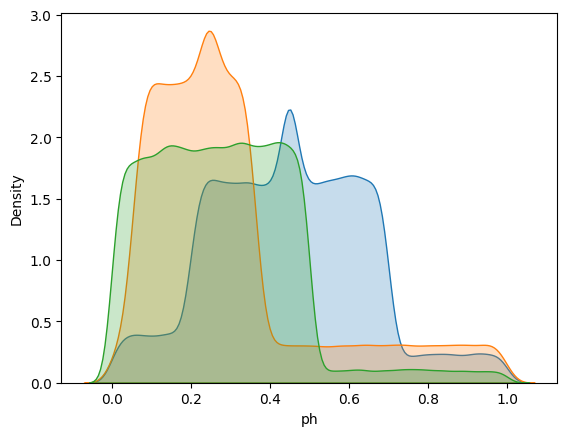

In [ ]:
# Creating a KDE plot
sns.kdeplot(X_train_norm,x="ph",fill=True)
sns.kdeplot(X_train_norm,x="tds",fill=True)
sns.kdeplot(X_train_norm,x="chlorine",fill=True)
plt.show()

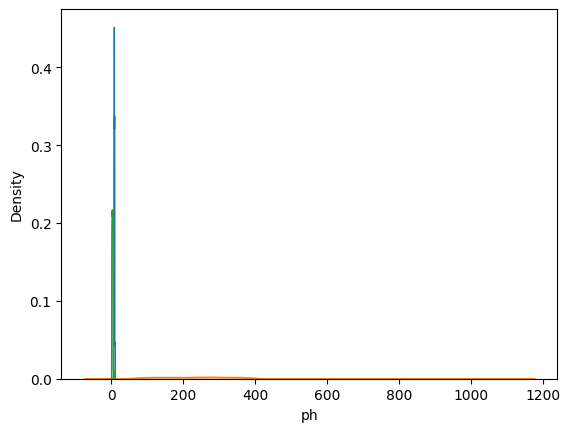

In [ ]:
# Create KDE PLot with Original Data
sns.kdeplot(X_train,x="ph",fill=True)
sns.kdeplot(X_train,x="tds",fill=True)
sns.kdeplot(X_train,x="chlorine",fill=True)
plt.show()

# **Standard Scalar**

In [ ]:
# standard scaler
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_stand=scaler.fit_transform(X_train)
X_test_stand=scaler.transform(X_test)

In [ ]:
X_train_stand=pd.DataFrame(X_train_stand,columns=X_train.columns)
X_train_stand.head()

,ph,tds,chlorine,sulfate,conductivity,organic_carbon,trihalomethanes,turbidity
0,-1.184434,1.109475,-1.183678,0.794225,0.185644,-0.552842,0.759610,0.485790
1,0.007815,-1.024163,-0.545687,0.728561,-0.420815,0.476363,-1.065627,0.945212
2,-0.379411,-0.799314,-0.750092,0.011974,-0.368145,0.050386,1.066128,-0.006744
3,1.434438,0.286441,-0.043966,0.127936,-0.371282,-0.292682,-1.192633,-0.830392
4,-1.011201,-1.028974,3.895470,0.459340,-0.049681,0.453492,-0.695904,0.266426


In [ ]:
X_test_stand=pd.DataFrame(X_test_stand,columns=X_train.columns)
X_test_stand.head()

,ph,tds,chlorine,sulfate,conductivity,organic_carbon,trihalomethanes,turbidity
0,-0.787017,0.266415,-0.186430,-1.052564,-0.182993,0.404890,-0.582767,-0.735196
1,-0.807398,2.625231,0.581636,-1.058868,-0.396032,-0.604302,0.014814,4.330861
2,-0.195988,-0.231764,-1.388082,-0.063867,0.073167,1.808611,-0.439514,-0.329581
3,0.761888,2.670012,-0.620016,-1.534929,-0.089324,-1.704979,-0.931290,-0.718640
4,0.058766,-0.650868,0.544472,2.671350,4.788950,-0.418473,2.147758,0.452678


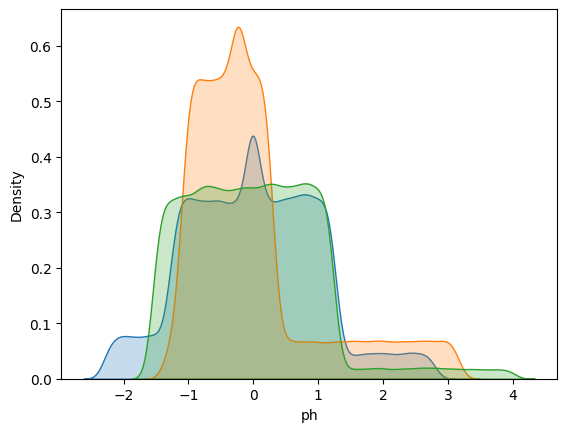

In [ ]:
sns.kdeplot(X_train_stand,x="ph",fill=True)
sns.kdeplot(X_train_stand,x="tds",fill=True)
sns.kdeplot(X_train_stand,x="chlorine",fill=True)
plt.show()

# **Robust Scalar**

In [ ]:
# robust scaler
from sklearn.preprocessing import RobustScaler
scaler=RobustScaler()
X_train_robust=scaler.fit_transform(X_train)
X_test_robust=scaler.transform(X_test)

In [ ]:
X_train_robust=pd.DataFrame(X_train_robust,columns=X_train.columns)
X_train_robust.head()

,ph,tds,chlorine,sulfate,conductivity,organic_carbon,trihalomethanes,turbidity
0,-0.804196,1.545393,-0.777778,0.694068,0.908768,-0.400000,0.568933,0.578947
1,0.013986,-0.895315,-0.337607,0.643325,-0.785281,0.305882,-0.650190,0.968421
2,-0.251748,-0.638106,-0.478632,0.089562,-0.638156,0.013725,0.773664,0.161404
3,0.993007,0.603909,0.008547,0.179175,-0.646919,-0.221569,-0.735021,-0.536842
4,-0.685315,-0.900818,2.726496,0.435277,0.251425,0.290196,-0.403242,0.392982


In [ ]:
X_test_robust=pd.DataFrame(X_test_robust,columns=X_train.columns)
X_test_robust.head()

,ph,tds,chlorine,sulfate,conductivity,organic_carbon,trihalomethanes,turbidity
0,-0.531469,0.581001,-0.089744,-0.733090,-0.120964,0.256863,-0.327676,-0.456140
1,-0.545455,3.279293,0.440171,-0.737961,-0.716055,-0.435294,0.071464,3.838596
2,-0.125874,0.011125,-0.918803,0.030953,0.594582,1.219608,-0.231993,-0.112281
3,0.531469,3.330519,-0.388889,-1.105851,0.140688,-1.190196,-0.560463,-0.442105
4,0.048951,-0.468296,0.414530,2.144669,13.767404,-0.307843,1.496112,0.550877


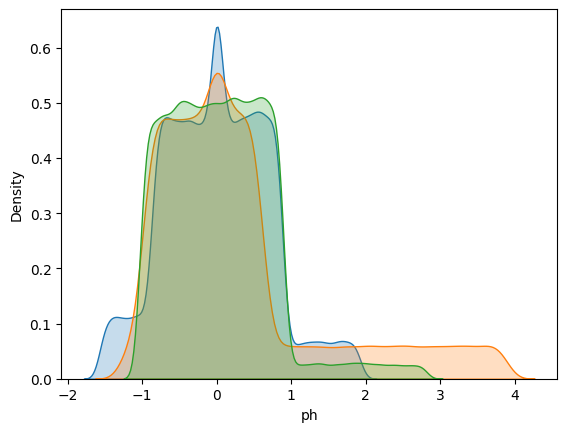

In [ ]:
sns.kdeplot(X_train_robust,x="ph",fill=True)
sns.kdeplot(X_train_robust,x="tds",fill=True)
sns.kdeplot(X_train_robust,x="chlorine",fill=True)
plt.show()

# **Standard Scalar**

- if the features are normally distributed

- it is not much impacted by outliers

In [ ]:
from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()
X_train_std=scalar.fit_transform(X_train)

In [ ]:
# Let us convert above data into a dataframe
X_train_std=pd.DataFrame(X_train_std,columns=X_train.columns)
X_train_std.head()

,ph,tds,chlorine,sulfate,conductivity,organic_carbon,trihalomethanes,turbidity
0,-0.158302,-0.533349,-1.347808,-0.986052,-0.141210,0.543856,-1.240947,0.921185
1,-2.029083,-0.503680,0.540992,-1.204533,0.061487,-0.630634,1.028990,-0.671051
2,0.802646,-0.574705,-0.983627,0.009835,-0.473947,-0.106105,-0.735921,-1.006913
3,-0.730781,-0.238097,0.929862,-0.660166,-0.168646,0.920149,-0.321057,-0.484461
4,-1.579278,0.281628,0.152121,0.582921,-0.069594,-0.738961,-1.413328,-0.389093


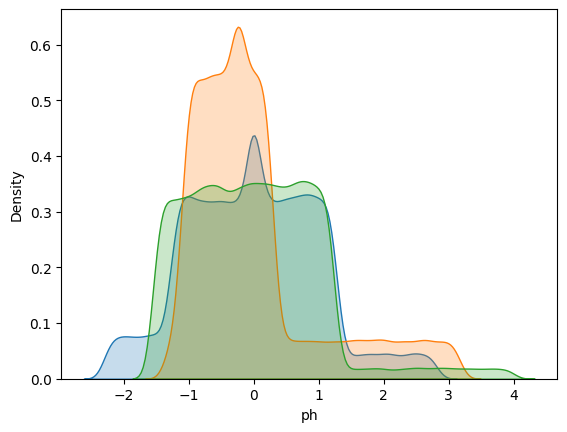

In [ ]:
sns.kdeplot(X_train_std,x="ph",fill=True)
sns.kdeplot(X_train_std,x="tds",fill=True)
sns.kdeplot(X_train_std,x="chlorine",fill=True)
plt.show()

In [ ]:
# let us apply standard scalar on test data
X_test_std=scalar.transform(X_test)
# let us convert transformed data into data frame
X_test_std=pd.DataFrame(X_test_std,columns=X_test.columns)
X_test_std.head()

,ph,tds,chlorine,sulfate,conductivity,organic_carbon,trihalomethanes,turbidity
0,-0.137856,-1.095623,1.090349,-1.466618,0.087111,0.541005,-0.210439,0.548004
1,-0.587662,-0.679966,1.003933,0.676622,-0.465314,-0.419682,-1.110669,0.788498
2,1.221783,-0.808889,-0.193541,-1.504453,-0.338854,-0.912854,-0.289679,-1.143746
3,0.199498,-0.983530,-1.193494,0.102355,0.179256,-0.776020,-0.874342,-0.604708
4,-1.241924,-1.020154,-1.168804,0.685408,-0.260064,0.666436,-0.636226,-0.065670


# **Robust Scalar**

In [ ]:
from sklearn.preprocessing import RobustScaler
scalar=RobustScaler(quantile_range=(20.0, 80.0))
# Let us apply Robust Scalar to Train Data
X_train_rob=scalar.fit_transform(X_train)
# Let us convert above numpy array into a data frame
X_train_rob=pd.DataFrame(X_train_rob,columns=X_train.columns)
X_train_rob.head()

,ph,tds,chlorine,sulfate,conductivity,organic_carbon,trihalomethanes,turbidity
0,-0.086705,-0.275616,-0.746429,-0.565292,0.001817,0.292683,-0.647616,0.803571
1,-1.144509,-0.247503,0.346429,-0.705198,0.476785,-0.377236,0.634492,-0.339286
2,0.456647,-0.314803,-0.535714,0.072430,-0.777864,-0.078049,-0.362367,-0.580357
3,-0.410405,0.004153,0.571429,-0.356609,-0.062471,0.507317,-0.128043,-0.205357
4,-0.890173,0.496623,0.121429,0.439410,0.169630,-0.439024,-0.744980,-0.136905


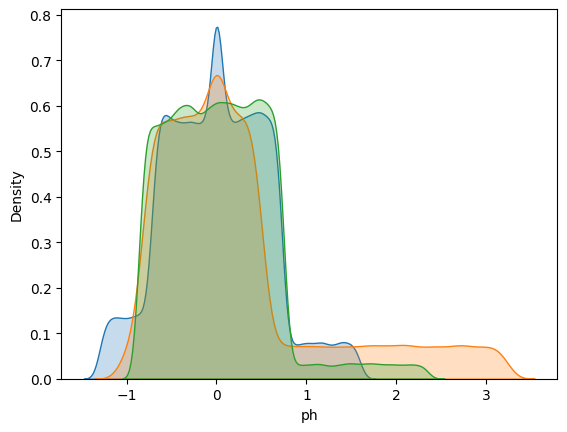

In [ ]:
sns.kdeplot(X_train_rob,x="ph",fill=True)
sns.kdeplot(X_train_rob,x="tds",fill=True)
sns.kdeplot(X_train_rob,x="chlorine",fill=True)
plt.show()

In [ ]:
# Let us apply robust scalar to test data
X_test_rob=scalar.transform(X_test)
# Let us convert above numpy array into a Data Frame
X_test_rob=pd.DataFrame(X_test_rob,columns=X_test.columns)
X_test_rob.head()

,ph,tds,chlorine,sulfate,conductivity,organic_carbon,trihalomethanes,turbidity
0,-0.075145,-0.808404,0.664286,-0.873027,0.536829,0.291057,-0.065564,0.535714
1,-0.329480,-0.414545,0.614286,0.499412,-0.757635,-0.256911,-0.574033,0.708333
2,0.693642,-0.536707,-0.078571,-0.897254,-0.461310,-0.538211,-0.110320,-0.678571
3,0.115607,-0.702190,-0.657143,0.131676,0.752746,-0.460163,-0.440550,-0.291667
4,-0.699422,-0.736893,-0.642857,0.505039,-0.276685,0.362602,-0.306057,0.095238
